Supportlytics — IT Support Ticket Analysis
Week 1: Data Acquisition & Understanding 




1.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

1.2 Load the dataset

In [2]:
df = pd.read_csv('helpdesk_tickets.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000000, 11)


,Ticket_ID,Date_Created,Date_Resolved,Category,Subcategory,Priority,Status,Assigned_Team,Resolution_Time_Hrs,Description,Escalated
0,1,2023-11-16,2023-11-23,Access,Access denied by auditor policy,Low,Open,Desktop Support,3.56,User reported Access denied by auditor policy....,True
1,2,2023-11-29,2023-12-02,Security,Suspicious DLL injection,Critical,Open,Security Team,4.14,User reported Suspicious DLL injection. Furthe...,False
2,3,2023-11-29,2023-12-06,Security,Suspicious SOC alert,Low,Pending,Security Team,2.98,User reported Suspicious SOC alert. Further in...,True
3,4,2023-11-04,2023-11-09,Software,App freezing,Low,On Hold,Application Support,4.45,User reported App freezing. Further investigat...,False
4,5,2023-11-03,2023-11-10,Access,Access logging failure,Critical,In Progress,Desktop Support,3.49,User reported Access logging failure. Further ...,True


1.3 Inspect structure, column types, and relationships

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Ticket_ID            1000000 non-null  int64  
 1   Date_Created         1000000 non-null  object 
 2   Date_Resolved        700057 non-null   object 
 3   Category             1000000 non-null  object 
 4   Subcategory          1000000 non-null  object 
 5   Priority             1000000 non-null  object 
 6   Status               1000000 non-null  object 
 7   Assigned_Team        1000000 non-null  object 
 8   Resolution_Time_Hrs  1000000 non-null  float64
 9   Description          1000000 non-null  object 
 10  Escalated            1000000 non-null  bool   
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 77.2+ MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,1000000.0,NaN,NaN,NaN,500000.5,288675.278932,1.0,250000.75,500000.5,750000.25,1000000.0
Date_Created,1000000,30,2023-11-03,33717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_Resolved,700057,36,2023-11-21,23507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000000,5,Software,200628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subcategory,1000000,493,Laptop touch screen not working,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,1000000,4,Low,250419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1000000,5,Resolved,200903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assigned_Team,1000000,4,Desktop Support,399425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hrs,1000000.0,NaN,NaN,NaN,5.246152,2.742932,0.5,2.87,5.24,7.62,10.0
Description,1000000,493,User reported Laptop touch screen not working....,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Unique value counts for categorical columns
cat_cols = ['Category', 'Subcategory', 'Priority', 'Status', 'Assigned_Team', 'Escalated']
for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- Category (5 unique) ---
Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64

--- Subcategory (493 unique) ---
Subcategory
Laptop touch screen not working           2166
Laptop motherboard short circuit          2161
Keyboard malfunction                      2149
DHCP failure                              2146
Suspicious cookie theft                   2141
                                          ... 
Access denied by SOX policy               1900
Access denied by HIPAA policy             1899
Access denied by auditor policy           1893
Access denied by temporary restriction    1892
Account disabled by policy                1887
Name: count, Length: 493, dtype: int64

--- Priority (4 unique) ---
Priority
Low         250419
Medium      250158
High        249853
Critical    249570
Name: count, dtype: int64

--- Status (5 unique) ---
Status
Resolved       200903
On Hold        200519
Open           199802


1.4 Missing values check

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Ticket_ID,0,0.00
Date_Created,0,0.00
Date_Resolved,299943,29.99
Category,0,0.00
Subcategory,0,0.00
Priority,0,0.00
Status,0,0.00
Assigned_Team,0,0.00
Resolution_Time_Hrs,0,0.00
Description,0,0.00


1.5 Duplicate check

In [7]:
print("Duplicate Ticket_IDs:", df['Ticket_ID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate Ticket_IDs: 0
Fully duplicate rows: 0


1.6 Define key metrics

In [8]:
df['Date_Created'] = pd.to_datetime(df['Date_Created'])
df['Date_Resolved'] = pd.to_datetime(df['Date_Resolved'])

priority_dist = df['Priority'].value_counts(normalize=True).mul(100).round(2)
print("Priority distribution (%):")
print(priority_dist)

Priority distribution (%):
Priority
Low         25.04
Medium      25.02
High        24.99
Critical    24.96
Name: proportion, dtype: float64


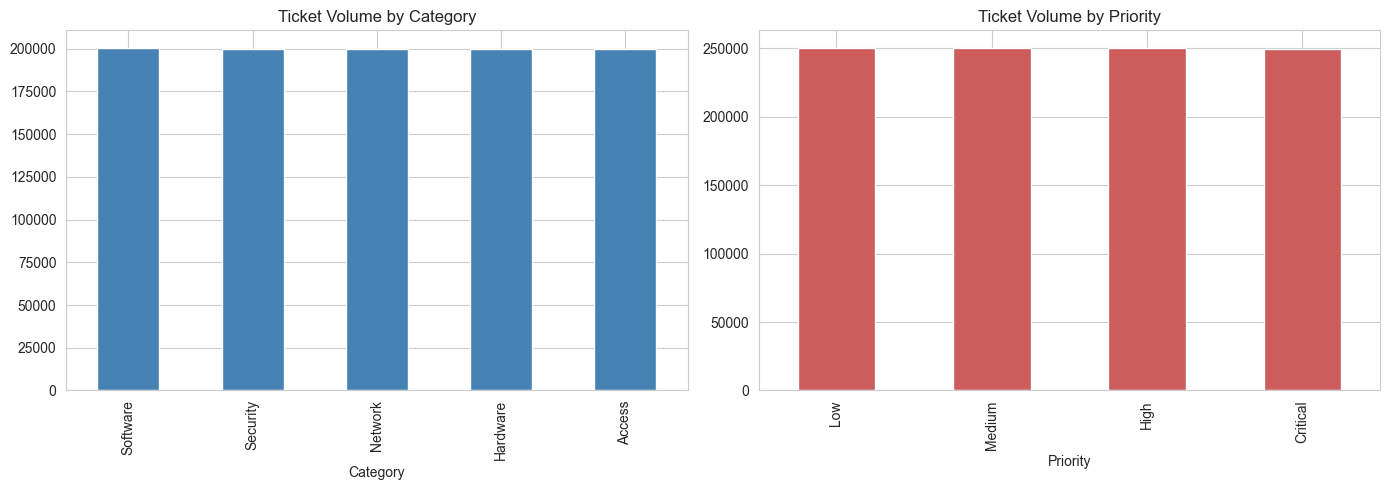

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Ticket Volume by Category')
df['Priority'].value_counts().plot(kind='bar', ax=axes[1], color='indianred', title='Ticket Volume by Priority')
plt.tight_layout()
plt.show()

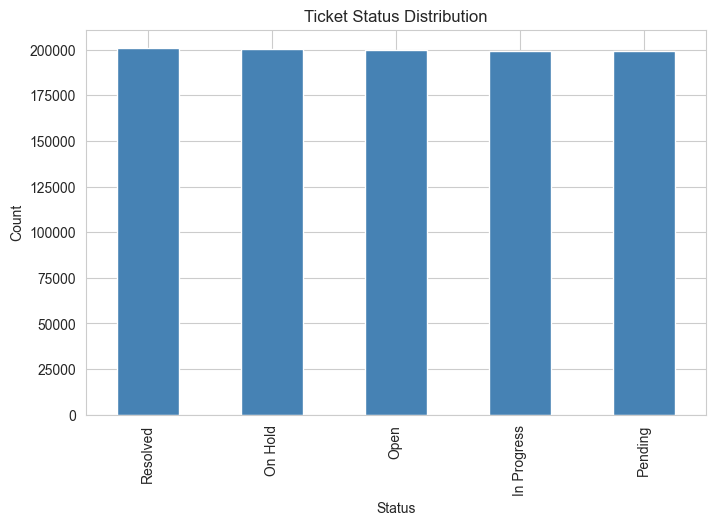

In [10]:
plt.figure(figsize=(8,5))
df['Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

Week 2 — Data Cleaning and Feature Engineering

2.1 Handle missing / incomplete fields


In [11]:
df['Is_Resolved'] = df['Date_Resolved'].notnull()
print(df['Is_Resolved'].value_counts())

# Cross-check against Status field
pd.crosstab(df['Status'], df['Is_Resolved'])

Is_Resolved
True     700057
False    299943
Name: count, dtype: int64


Is_Resolved,False,True
Status,,
In Progress,59593,139842
On Hold,59951,140568
Open,60044,139758
Pending,60031,139310
Resolved,60324,140579


2.2 Extract Resolution_Time


In [12]:
df['Resolution_Time_Days'] = (df['Date_Resolved'] - df['Date_Created']).dt.days
df['Resolution_Time_Computed_Hrs'] = df['Resolution_Time_Days'] * 24

df[['Ticket_ID', 'Date_Created', 'Date_Resolved',
    'Resolution_Time_Hrs', 'Resolution_Time_Computed_Hrs']].head(10)

,Ticket_ID,Date_Created,Date_Resolved,Resolution_Time_Hrs,Resolution_Time_Computed_Hrs
0,1,2023-11-16,2023-11-23,3.56,168.0
1,2,2023-11-29,2023-12-02,4.14,72.0
2,3,2023-11-29,2023-12-06,2.98,168.0
3,4,2023-11-04,2023-11-09,4.45,120.0
4,5,2023-11-03,2023-11-10,3.49,168.0
5,6,2023-11-04,NaT,5.29,NaN
6,7,2023-11-20,2023-11-25,8.98,120.0
7,8,2023-11-17,2023-11-20,7.78,72.0
8,9,2023-11-28,2023-12-05,6.57,168.0
9,10,2023-11-30,2023-12-05,8.77,120.0


In [13]:
# Sanity check: distribution of the recomputed metric for resolved tickets
resolved = df[df['Is_Resolved']]
resolved['Resolution_Time_Computed_Hrs'].describe()

count    700057.000000
mean         95.965786
std          48.003193
min          24.000000
25%          48.000000
50%          96.000000
75%         144.000000
max         168.000000
Name: Resolution_Time_Computed_Hrs, dtype: float64

2.3 Categorize performance buckets

In [14]:
def bucket_resolution(hours):
    if pd.isna(hours):
        return 'Unresolved'
    elif hours <= 48:
        return 'Fast'
    elif hours <= 120:
        return 'Moderate'
    else:
        return 'Slow'

df['Performance_Bucket'] = df['Resolution_Time_Computed_Hrs'].apply(bucket_resolution)
df['Performance_Bucket'].value_counts()

Performance_Bucket
Moderate      300377
Unresolved    299943
Fast          200230
Slow          199450
Name: count, dtype: int64

2.4 Encode categorical fields

In [15]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\MADHU BABU REPALLI\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [16]:
from sklearn.preprocessing import LabelEncoder

# Ordinal encode Priority (has a natural order)
priority_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['Priority_Encoded'] = df['Priority'].map(priority_order)

# One-hot encode nominal fields for downstream modeling/clustering
df_encoded = pd.get_dummies(
    df,
    columns=['Category', 'Status', 'Assigned_Team', 'Performance_Bucket'],
    prefix=['Cat', 'Status', 'Team', 'Perf']
)

# Label encode Subcategory (high cardinality -> keep as single numeric column)
le = LabelEncoder()
df['Subcategory_Encoded'] = le.fit_transform(df['Subcategory'])

df_encoded.head()

,Ticket_ID,Date_Created,Date_Resolved,Subcategory,Priority,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Priority_Encoded,Cat_Access,Cat_Hardware,Cat_Network,Cat_Security,Cat_Software,Status_In Progress,Status_On Hold,Status_Open,Status_Pending,Status_Resolved,Team_Application Support,Team_Desktop Support,Team_Network Team,Team_Security Team,Perf_Fast,Perf_Moderate,Perf_Slow,Perf_Unresolved
0,1,2023-11-16,2023-11-23,Access denied by auditor policy,Low,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,0,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
1,2,2023-11-29,2023-12-02,Suspicious DLL injection,Critical,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,3,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False
2,3,2023-11-29,2023-12-06,Suspicious SOC alert,Low,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,0,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False
3,4,2023-11-04,2023-11-09,App freezing,Low,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,0,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False
4,5,2023-11-03,2023-11-10,Access logging failure,Critical,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,3,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False


In [17]:
from sklearn.preprocessing import LabelEncoder

# Ordinal encode Priority (has a natural order)
priority_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['Priority_Encoded'] = df['Priority'].map(priority_order)

# One-hot encode nominal fields for downstream modeling/clustering
df_encoded = pd.get_dummies(
    df,
    columns=['Category', 'Status', 'Assigned_Team', 'Performance_Bucket'],
    prefix=['Cat', 'Status', 'Team', 'Perf']
)

# Label encode Subcategory (high cardinality -> keep as single numeric column)
le = LabelEncoder()
df['Subcategory_Encoded'] = le.fit_transform(df['Subcategory'])

df_encoded.head()

,Ticket_ID,Date_Created,Date_Resolved,Subcategory,Priority,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Priority_Encoded,Subcategory_Encoded,Cat_Access,Cat_Hardware,Cat_Network,Cat_Security,Cat_Software,Status_In Progress,Status_On Hold,Status_Open,Status_Pending,Status_Resolved,Team_Application Support,Team_Desktop Support,Team_Network Team,Team_Security Team,Perf_Fast,Perf_Moderate,Perf_Slow,Perf_Unresolved
0,1,2023-11-16,2023-11-23,Access denied by auditor policy,Low,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,0,29,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
1,2,2023-11-29,2023-12-02,Suspicious DLL injection,Critical,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,3,396,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False
2,3,2023-11-29,2023-12-06,Suspicious SOC alert,Low,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,0,415,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False
3,4,2023-11-04,2023-11-09,App freezing,Low,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,0,76,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False
4,5,2023-11-03,2023-11-10,Access logging failure,Critical,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,3,61,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False


2.5 Save the cleaned dataset

In [18]:
df.to_csv('helpdesk_tickets_cleaned.csv', index=False)
df_encoded.to_csv('helpdesk_tickets_encoded.csv', index=False)
print("Saved cleaned and encoded datasets.")
print("df shape:", df.shape, "| df_encoded shape:", df_encoded.shape)

Saved cleaned and encoded datasets.
df shape: (1000000, 17) | df_encoded shape: (1000000, 31)


## Week 3 — Module 3: Exploratory Visualization

### 3.0 Load the cleaned dataset
Continuing from the cleaned output of Module 2.

In [19]:
df = pd.read_csv('helpdesk_tickets_cleaned.csv')
df['Date_Created'] = pd.to_datetime(df['Date_Created'])
df['Date_Resolved'] = pd.to_datetime(df['Date_Resolved'])
print(df.shape)
df.head()

(1000000, 17)


,Ticket_ID,Date_Created,Date_Resolved,Category,Subcategory,Priority,Status,Assigned_Team,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Performance_Bucket,Priority_Encoded,Subcategory_Encoded
0,1,2023-11-16,2023-11-23,Access,Access denied by auditor policy,Low,Open,Desktop Support,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,Slow,0,29
1,2,2023-11-29,2023-12-02,Security,Suspicious DLL injection,Critical,Open,Security Team,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,Moderate,3,396
2,3,2023-11-29,2023-12-06,Security,Suspicious SOC alert,Low,Pending,Security Team,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,Slow,0,415
3,4,2023-11-04,2023-11-09,Software,App freezing,Low,On Hold,Application Support,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,Moderate,0,76
4,5,2023-11-03,2023-11-10,Access,Access logging failure,Critical,In Progress,Desktop Support,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,Slow,3,61


### 3.1 Ticket type distribution
This dataset doesn't carry a separate `Ticket_Type` field, so `Category` is the closest equivalent —
it's the top-level classification every ticket is routed under.

Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64


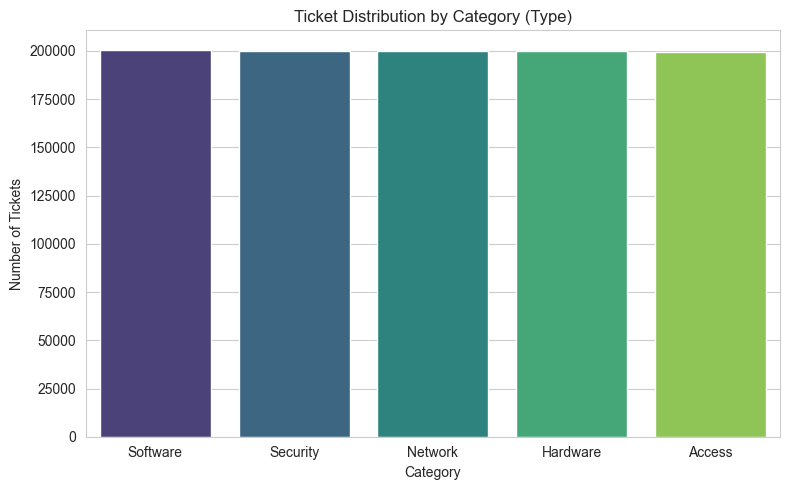

In [20]:
category_counts = df['Category'].value_counts()
print(category_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index,
            palette='viridis', legend=False)
plt.title('Ticket Distribution by Category (Type)')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

3.2 Top categories and clusters by frequency

Top Categories:
Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64


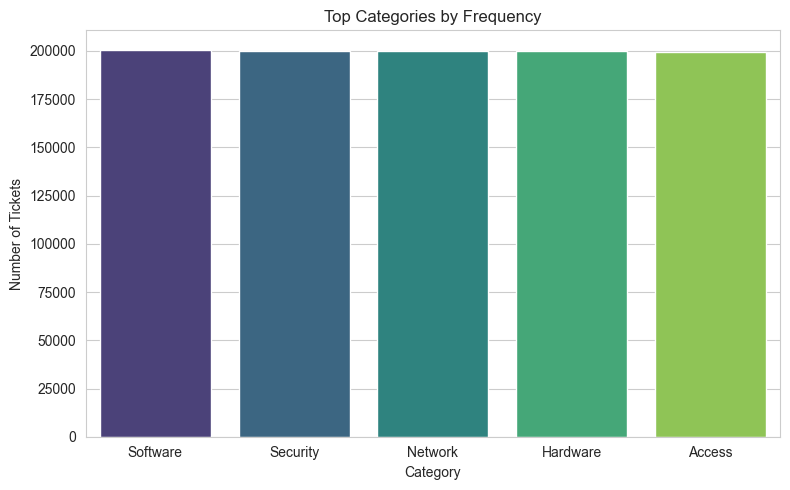

In [21]:
# --- Categories: top-level classification 
top_categories = df['Category'].value_counts()
print("Top Categories:")
print(top_categories)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.index, y=top_categories.values, hue=top_categories.index,
            palette='viridis', legend=False)
plt.title('Top Categories by Frequency')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

Top 15 Clusters / Subcategories by Frequency:
Subcategory
Laptop touch screen not working     2166
Laptop motherboard short circuit    2161
Keyboard malfunction                2149
DHCP failure                        2146
Suspicious cookie theft             2141
Laptop won’t power on               2140
Laptop screen ghost image           2139
Laptop screen black screen          2136
Laptop screen blue tint             2134
Access denied by server             2131
Duplicate IP detected               2129
Suspicious contractor compromise    2127
External HDD not mounting           2127
Database connection error           2127
CD/DVD drive not working            2122
Name: count, dtype: int64


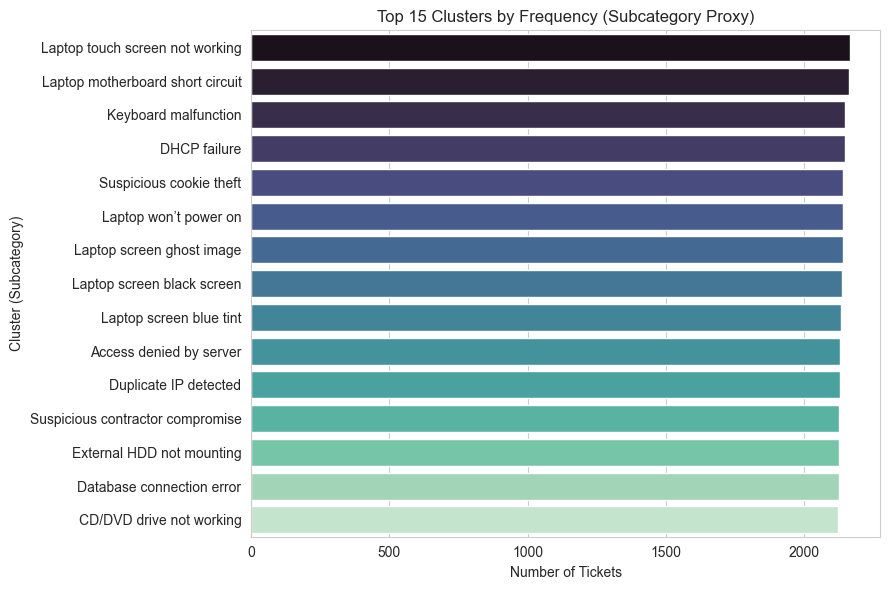

In [22]:
# --- Clusters (proxy): Subcategory as the finer-grained issue grouping ---
top_clusters = df['Subcategory'].value_counts().head(15)
print("Top 15 Clusters / Subcategories by Frequency:")
print(top_clusters)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_clusters.values, y=top_clusters.index, hue=top_clusters.index,
            palette='mako', legend=False)
plt.title('Top 15 Clusters by Frequency (Subcategory Proxy)')
plt.xlabel('Number of Tickets')
plt.ylabel('Cluster (Subcategory)')
plt.tight_layout()
plt.show()

### 3.3 Tickets by priority

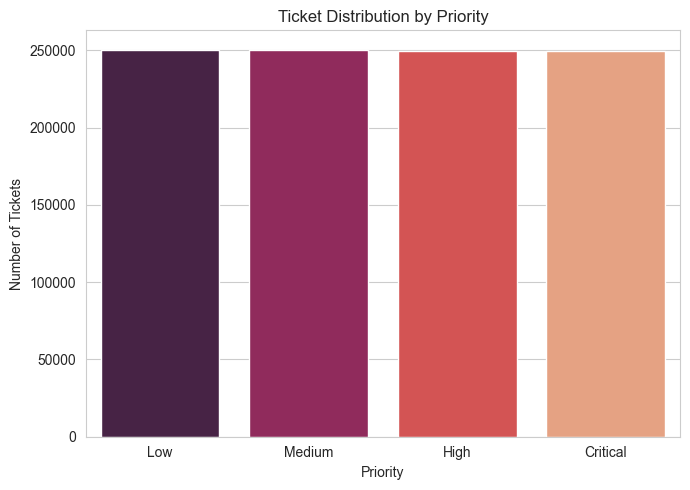

In [23]:
priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_counts = df['Priority'].value_counts().reindex(priority_order)

plt.figure(figsize=(7, 5))
sns.barplot(x=priority_counts.index, y=priority_counts.values, hue=priority_counts.index,
            order=priority_order, palette='rocket', legend=False)
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

### 3.4 Tickets by queue (Assigned_Team)
`Assigned_Team` is the operational "queue" each ticket sits in before being worked.

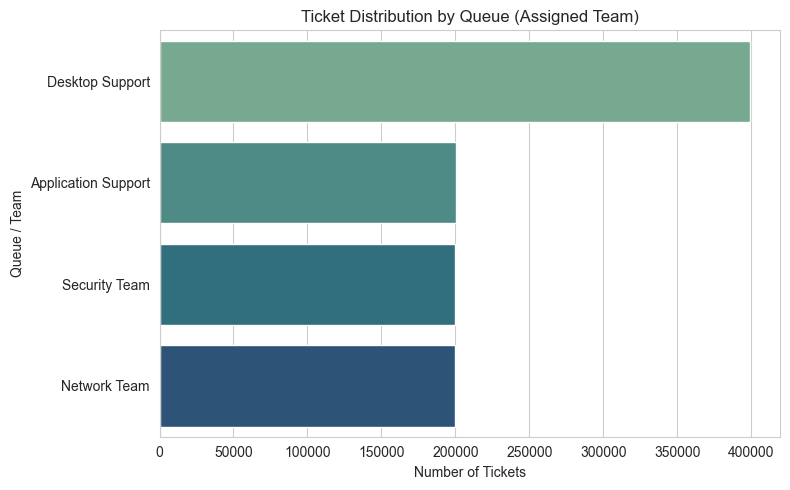

In [24]:
queue_counts = df['Assigned_Team'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=queue_counts.values, y=queue_counts.index, hue=queue_counts.index,
            palette='crest', legend=False)
plt.title('Ticket Distribution by Queue (Assigned Team)')
plt.xlabel('Number of Tickets')
plt.ylabel('Queue / Team')
plt.tight_layout()
plt.show()

### 3.5 Priority x Queue — combined view

Priority               Low  Medium   High  Critical
Assigned_Team                                      
Application Support  50563   50145  50071     49849
Desktop Support      99972  100023  99823     99607
Network Team         49879   49967  49915     50182
Security Team        50005   50023  50044     49932


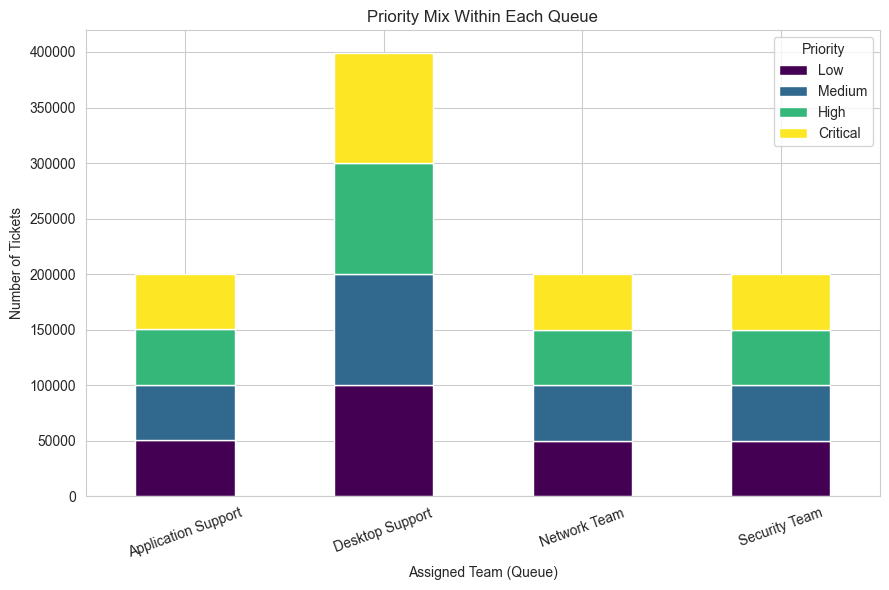

In [25]:
priority_queue = pd.crosstab(df['Assigned_Team'], df['Priority'])[priority_order]
print(priority_queue)

priority_queue.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='viridis')
plt.title('Priority Mix Within Each Queue')
plt.xlabel('Assigned Team (Queue)')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.legend(title='Priority')
plt.tight_layout()
plt.show()

### Observations
- Category and Priority are both close to evenly distributed (~20% and ~25% respectively) — confirmed in Module 1
  and unchanged here, so volume isn't where the interesting signal lives.
- Desktop Support carries roughly 2x the ticket load of any other queue.
- Subcategory frequency gives an early proxy for "clusters" of similar issues; the actual similarity-based
  clustering (Cluster_ID, Similarity_Score, Similarity_Level) is planned for the next milestone using these
  Subcategory and Description fields as clustering input.